In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [4]:
df = pd.read_csv('../dados/df_regressao.csv')

In [7]:
# Filtrando apenas os meses de Verão (Dezembro, Janeiro, Fevereiro)
meses_verao = [12, 1, 2]
df_verao = df[df['mes'].isin(meses_verao)]

# Tirar a média dos verões de 2020 ate 2023 para cada bairro
df_verao_bairros = df_verao.groupby('bairro').mean(numeric_only=True).reset_index()

X = df_verao_bairros[['percentual_verde']]
y = df_verao_bairros['temp_max_media']

In [10]:
modelo = LinearRegression()
modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Resultados Técnicos
coef = modelo.coef_[0]  # valor de "a" - inclinacao da reta
intercept = modelo.intercept_  # valor de "b" - onde a reta corta o eixo Y
r2 = modelo.score(X, y)

print(f"Equação: Temp = {coef:.2f} * %Verde + {intercept:.2f}")
print(f"R² (Poder de explicação): {r2:.2f}")

Equação: Temp = 0.04 * %Verde + 29.53
R² (Poder de explicação): 0.05


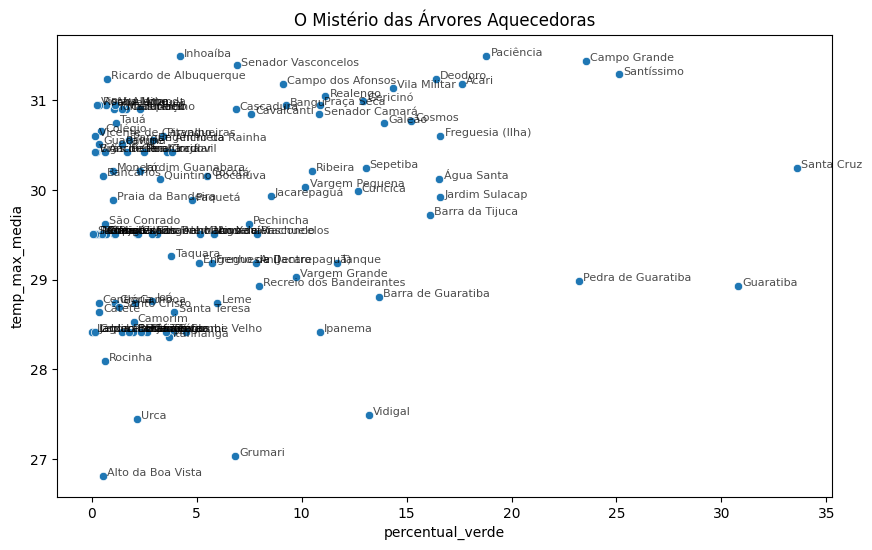

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_verao_bairros, x='percentual_verde', y='temp_max_media')
# Adiciona os nomes dos bairros nos pontos para ver quem são os outliers
for i in range(df_verao_bairros.shape[0]):
    plt.text(df_verao_bairros.percentual_verde[i]+0.2, 
             df_verao_bairros.temp_max_media[i], 
             df_verao_bairros.bairro[i], fontsize=8, alpha=0.7)
plt.title("O Mistério das Árvores Aquecedoras")
plt.savefig('../assets/temperatura_por_%verde.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
print(df_verao_bairros[['percentual_verde', 'temp_max_media']].corr())

                  percentual_verde  temp_max_media
percentual_verde          1.000000        0.228846
temp_max_media            0.228846        1.000000


Observamos um R² baixo e um coeficiente positivo, o que sugere que o fenômeno térmico no Rio não é linear e sofre forte influência da maritimidade e continentalidade. Isso justifica a transição para um modelo de vulnerabilidade multicritério.